## 1. Loading the Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/College/Fall 2026 (UTS)/Machine Learning/game.csv'

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(file_path)

pd.set_option('display.max_columns', None) # Display all the columns

print(len(df))

df.head()

65698


,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,plus_minus_home,video_available_home,team_id_away,team_abbreviation_away,team_name_away,matchup_away,wl_away,fgm_away,fga_away,fg_pct_away,fg3m_away,fg3a_away,fg3_pct_away,ftm_away,fta_away,ft_pct_away,oreb_away,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away,season_type
0,21946,1610610035,HUS,Toronto Huskies,24600001,1946-11-01 00:00:00,HUS vs. NYK,L,0,25.0,NaN,NaN,NaN,NaN,NaN,16.0,29.0,0.552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.0,-2,0,1610612752,NYK,New York Knicks,NYK @ HUS,W,24.0,NaN,NaN,NaN,NaN,NaN,20.0,26.0,0.769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.0,2,0,Regular Season
1,21946,1610610034,BOM,St. Louis Bombers,24600003,1946-11-02 00:00:00,BOM vs. PIT,W,0,20.0,59.0,0.339,NaN,NaN,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,56.0,5,0,1610610031,PIT,Pittsburgh Ironmen,PIT @ BOM,L,16.0,72.0,0.222,NaN,NaN,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,51.0,-5,0,Regular Season
2,21946,1610610032,PRO,Providence Steamrollers,24600002,1946-11-02 00:00:00,PRO vs. BOS,W,0,21.0,NaN,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,6,0,1610612738,BOS,Boston Celtics,BOS @ PRO,L,21.0,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.0,-6,0,Regular Season
3,21946,1610610025,CHS,Chicago Stags,24600004,1946-11-02 00:00:00,CHS vs. NYK,W,0,21.0,NaN,NaN,NaN,NaN,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,63.0,16,0,1610612752,NYK,New York Knicks,NYK @ CHS,L,16.0,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,47.0,-16,0,Regular Season
4,21946,1610610028,DEF,Detroit Falcons,24600005,1946-11-02 00:00:00,DEF vs. WAS,L,0,10.0,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,-17,0,1610610036,WAS,Washington Capitols,WAS @ DEF,W,18.0,NaN,NaN,NaN,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,17,0,Regular Season


## 2. Data Preprocessing

In [ ]:
# Delete missing values
df = df.dropna()

# Drop Unneeded Columns
df = df.drop(columns = ['video_available_home', 'video_available_away', 'team_id_home', 'team_id_away', 'team_name_home', 'team_name_away', 'fga_home', 'fgm_home', 'fga_away', 'matchup_home', 'matchup_away', 'min',  'fg3m_home', 'fg3a_home', 'fg3m_away', 'fg3a_away', 'ftm_home', 'fta_home', 'ftm_away', 'fta_away', 'plus_minus_home', 'plus_minus_away'])

print(len(df))
df.head()



46154


,season_id,team_abbreviation_home,game_id,game_date,wl_home,fg_pct_home,fg3_pct_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,team_abbreviation_away,wl_away,fgm_away,fg_pct_away,fg3_pct_away,ft_pct_away,oreb_away,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,season_type
14166,41979,LAL,47900044,1980-05-07 00:00:00,L,0.505,0.00,0.667,15.0,37.0,52.0,32.0,12.0,7.0,26.0,27.0,104.0,PHL,W,43.0,0.506,0.0,0.778,5.0,29.0,34.0,34.0,14.0,11.0,20.0,21.0,107.0,Playoffs
14167,41979,PHL,47900045,1980-05-10 00:00:00,L,0.484,0.25,0.588,13.0,24.0,37.0,34.0,12.0,8.0,13.0,25.0,101.0,LAL,W,44.0,0.478,0.0,0.767,22.0,34.0,56.0,20.0,5.0,5.0,20.0,25.0,111.0,Playoffs
14170,41979,PHL,47900048,1980-05-16 00:00:00,L,0.528,0.00,0.591,7.0,29.0,36.0,27.0,4.0,11.0,18.0,27.0,107.0,LAL,W,45.0,0.489,0.0,0.943,17.0,35.0,52.0,27.0,14.0,4.0,17.0,22.0,123.0,Playoffs
14171,31979,EST,37900001,1980-02-03 00:00:00,W,0.468,0.50,0.614,31.0,31.0,62.0,34.0,20.0,9.0,30.0,30.0,144.0,WST,L,53.0,0.465,0.0,0.811,24.0,31.0,55.0,34.0,17.0,16.0,29.0,32.0,136.0,All-Star
14172,31979,EST,37900001,1980-02-03 00:00:00,W,0.468,0.50,0.614,31.0,31.0,62.0,34.0,20.0,9.0,30.0,30.0,144.0,WST,L,53.0,0.465,0.0,0.811,24.0,31.0,55.0,34.0,17.0,16.0,29.0,32.0,136.0,All Star


In [ ]:
df = df.rename(columns={"team_abbreviation_home": "team_home", "team_abbreviation_away": "team_away"})

df

,season_id,team_home,game_id,game_date,wl_home,fg_pct_home,fg3_pct_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,team_away,wl_away,fgm_away,fg_pct_away,fg3_pct_away,ft_pct_away,oreb_away,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,season_type
14166,41979,LAL,47900044,1980-05-07 00:00:00,L,0.505,0.000,0.667,15.0,37.0,52.0,32.0,12.0,7.0,26.0,27.0,104.0,PHL,W,43.0,0.506,0.000,0.778,5.0,29.0,34.0,34.0,14.0,11.0,20.0,21.0,107.0,Playoffs
14167,41979,PHL,47900045,1980-05-10 00:00:00,L,0.484,0.250,0.588,13.0,24.0,37.0,34.0,12.0,8.0,13.0,25.0,101.0,LAL,W,44.0,0.478,0.000,0.767,22.0,34.0,56.0,20.0,5.0,5.0,20.0,25.0,111.0,Playoffs
14170,41979,PHL,47900048,1980-05-16 00:00:00,L,0.528,0.000,0.591,7.0,29.0,36.0,27.0,4.0,11.0,18.0,27.0,107.0,LAL,W,45.0,0.489,0.000,0.943,17.0,35.0,52.0,27.0,14.0,4.0,17.0,22.0,123.0,Playoffs
14171,31979,EST,37900001,1980-02-03 00:00:00,W,0.468,0.500,0.614,31.0,31.0,62.0,34.0,20.0,9.0,30.0,30.0,144.0,WST,L,53.0,0.465,0.000,0.811,24.0,31.0,55.0,34.0,17.0,16.0,29.0,32.0,136.0,All-Star
14172,31979,EST,37900001,1980-02-03 00:00:00,W,0.468,0.500,0.614,31.0,31.0,62.0,34.0,20.0,9.0,30.0,30.0,144.0,WST,L,53.0,0.465,0.000,0.811,24.0,31.0,55.0,34.0,17.0,16.0,29.0,32.0,136.0,All Star
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65691,42022,DEN,42200401,2023-06-01 00:00:00,W,0.506,0.296,0.800,6.0,39.0,45.0,29.0,4.0,4.0,10.0,8.0,104.0,MIA,L,39.0,0.406,0.333,1.000,11.0,32.0,43.0,26.0,5.0,4.0,8.0,15.0,93.0,Playoffs
65692,42022,DEN,42200402,2023-06-04 00:00:00,L,0.520,0.393,0.864,9.0,29.0,38.0,23.0,7.0,2.0,14.0,21.0,108.0,MIA,W,38.0,0.487,0.486,0.900,8.0,23.0,31.0,28.0,5.0,4.0,11.0,22.0,111.0,Playoffs
65693,42022,MIA,42200403,2023-06-07 00:00:00,L,0.370,0.314,0.789,10.0,23.0,33.0,20.0,7.0,3.0,4.0,22.0,94.0,DEN,W,41.0,0.513,0.278,0.815,13.0,45.0,58.0,28.0,3.0,5.0,14.0,18.0,109.0,Playoffs
65694,42022,MIA,42200404,2023-06-09 00:00:00,L,0.449,0.320,0.850,8.0,29.0,37.0,23.0,2.0,3.0,15.0,19.0,95.0,DEN,W,39.0,0.494,0.500,0.762,5.0,29.0,34.0,26.0,11.0,7.0,8.0,18.0,108.0,Playoffs


In [ ]:
# Filter dataframe to only keep Regular Season Games
df = df[df['season_type'] == 'Regular Season']

# Drop season type column now since there is no longer use for it
df = df.drop(columns = 'season_type')


In [ ]:
# Get data from the last 10 nba seasons (2013-2023)
seasons = sorted(df['season_id'].unique())

last_10_seasons = seasons[-10:]

df = df[df['season_id'].isin(last_10_seasons)]

df

,season_id,team_home,game_id,game_date,wl_home,fg_pct_home,fg3_pct_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,team_away,wl_away,fgm_away,fg_pct_away,fg3_pct_away,ft_pct_away,oreb_away,dreb_away,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away
52158,22013,LAL,21300003,2013-10-29 00:00:00,W,0.452,0.483,0.643,18.0,34.0,52.0,23.0,8.0,6.0,19.0,23.0,116.0,LAC,L,41.0,0.494,0.381,0.565,10.0,30.0,40.0,27.0,11.0,4.0,16.0,21.0,103.0
52159,22013,IND,21300001,2013-10-29 00:00:00,W,0.479,0.412,0.688,10.0,34.0,44.0,17.0,4.0,18.0,21.0,13.0,97.0,ORL,L,36.0,0.387,0.474,0.600,13.0,26.0,39.0,17.0,10.0,6.0,19.0,26.0,87.0
52160,22013,MIA,21300002,2013-10-29 00:00:00,W,0.514,0.550,0.759,5.0,35.0,40.0,26.0,10.0,7.0,20.0,21.0,107.0,CHI,L,35.0,0.422,0.269,0.783,11.0,30.0,41.0,23.0,11.0,4.0,19.0,27.0,95.0
52161,22013,MIN,21300010,2013-10-30 00:00:00,W,0.420,0.320,0.824,14.0,35.0,49.0,27.0,7.0,3.0,15.0,19.0,120.0,ORL,L,47.0,0.470,0.370,0.611,14.0,40.0,54.0,21.0,7.0,6.0,18.0,29.0,115.0
52162,22013,SAS,21300013,2013-10-30 00:00:00,W,0.526,0.550,0.625,4.0,36.0,40.0,25.0,3.0,6.0,15.0,18.0,101.0,MEM,L,39.0,0.419,0.533,0.533,11.0,33.0,44.0,24.0,6.0,3.0,14.0,15.0,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65537,22022,NYK,22201220,2023-04-09 00:00:00,L,0.481,0.375,0.773,19.0,34.0,53.0,29.0,8.0,8.0,15.0,24.0,136.0,IND,W,46.0,0.517,0.559,0.789,8.0,36.0,44.0,33.0,8.0,9.0,15.0,24.0,141.0
65538,22022,BKN,22201217,2023-04-09 00:00:00,L,0.422,0.375,0.821,10.0,32.0,42.0,22.0,6.0,6.0,19.0,22.0,105.0,PHI,W,53.0,0.525,0.438,0.737,13.0,37.0,50.0,31.0,10.0,5.0,13.0,23.0,134.0
65539,22022,CHI,22201223,2023-04-09 00:00:00,W,0.421,0.200,0.773,11.0,37.0,48.0,21.0,15.0,7.0,4.0,16.0,103.0,DET,L,31.0,0.365,0.273,0.769,15.0,44.0,59.0,20.0,1.0,3.0,25.0,16.0,81.0
65540,22022,TOR,22201221,2023-04-09 00:00:00,W,0.505,0.333,0.875,7.0,38.0,45.0,29.0,8.0,2.0,9.0,19.0,121.0,MIL,L,38.0,0.463,0.353,0.810,7.0,31.0,38.0,28.0,5.0,2.0,14.0,13.0,105.0


## 3. Feature Engineering

In [ ]:
# Group all home teams together (currently split between home and away)

home_df = df[['game_id', 'game_date', 'team_home','fg_pct_home', 'fg3_pct_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home', 'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home', 'pts_home']].copy()

home_df = home_df.rename(columns={
    'team_home': 'team',
    'fg_pct_home': 'fg_pct',
    'fg3_pct_home': 'fg3_pct',
    'ft_pct_home': 'ft_pct',
    'oreb_home': 'oreb',
    'dreb_home': 'dreb',
    'reb_home': 'reb',
    'ast_home': 'ast',
    'stl_home': 'stl',
    'blk_home': 'blk',
    'tov_home': 'tov',
    'pf_home': 'pf',
    'pts_home': 'pts'
})

home_df['is_home'] = 1 # This keeps track of where all the teams play

away_df = df[['game_id', 'game_date', 'team_away','fg_pct_away', 'fg3_pct_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away', 'ast_away', 'stl_away', 'blk_away', 'tov_away', 'pf_away', 'pts_away']].copy()

away_df = away_df.rename(columns={
    'team_away': 'team',
    'fg_pct_away': 'fg_pct',
    'fg3_pct_away': 'fg3_pct',
    'ft_pct_away': 'ft_pct',
    'oreb_away': 'oreb',
    'dreb_away': 'dreb',
    'reb_away': 'reb',
    'ast_away': 'ast',
    'stl_away': 'stl',
    'blk_away': 'blk',
    'tov_away': 'tov',
    'pf_away': 'pf',
    'pts_away': 'pts'
})

away_df['is_home'] = 0

# Stack them on eachother in the dataframe
stacked_df = pd.concat([home_df, away_df], ignore_index=True)

stacked_df




,game_id,game_date,team,fg_pct,fg3_pct,ft_pct,oreb,dreb,reb,ast,stl,blk,tov,pf,pts,is_home
0,21300003,2013-10-29 00:00:00,LAL,0.452,0.483,0.643,18.0,34.0,52.0,23.0,8.0,6.0,19.0,23.0,116.0,1
1,21300001,2013-10-29 00:00:00,IND,0.479,0.412,0.688,10.0,34.0,44.0,17.0,4.0,18.0,21.0,13.0,97.0,1
2,21300002,2013-10-29 00:00:00,MIA,0.514,0.550,0.759,5.0,35.0,40.0,26.0,10.0,7.0,20.0,21.0,107.0,1
3,21300010,2013-10-30 00:00:00,MIN,0.420,0.320,0.824,14.0,35.0,49.0,27.0,7.0,3.0,15.0,19.0,120.0,1
4,21300013,2013-10-30 00:00:00,SAS,0.526,0.550,0.625,4.0,36.0,40.0,25.0,3.0,6.0,15.0,18.0,101.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23953,22201220,2023-04-09 00:00:00,IND,0.517,0.559,0.789,8.0,36.0,44.0,33.0,8.0,9.0,15.0,24.0,141.0,0
23954,22201217,2023-04-09 00:00:00,PHI,0.525,0.438,0.737,13.0,37.0,50.0,31.0,10.0,5.0,13.0,23.0,134.0,0
23955,22201223,2023-04-09 00:00:00,DET,0.365,0.273,0.769,15.0,44.0,59.0,20.0,1.0,3.0,25.0,16.0,81.0,0
23956,22201221,2023-04-09 00:00:00,MIL,0.463,0.353,0.810,7.0,31.0,38.0,28.0,5.0,2.0,14.0,13.0,105.0,0


In [ ]:
# Calculate the rolling averages (Average stats over the last 10 games)

# Sort the data by time
stacked_df = stacked_df.sort_values(by=['team', 'game_date'])


rolling_stats = ['fg_pct', 'fg3_pct', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts']

# create the new column names for the average stats over the course of the 10 games
rolling_cols = [f"{stat}_10g" for stat in rolling_stats]

def getRollingAvg(x):
  #shift(1) makes sure you don't look at the current game just the previous ones
  return x.shift(1).rolling(window=10, min_periods=1).mean()

stacked_df[rolling_cols] = stacked_df.groupby('team')[rolling_stats].transform(getRollingAvg)

stacked_df.head()

,game_id,game_date,team,fg_pct,fg3_pct,ft_pct,oreb,dreb,reb,ast,stl,blk,tov,pf,pts,is_home,fg_pct_10g,fg3_pct_10g,ft_pct_10g,oreb_10g,dreb_10g,reb_10g,ast_10g,stl_10g,blk_10g,tov_10g,pf_10g,pts_10g
11989,21300012,2013-10-30 00:00:00,ATL,0.487,0.333,0.771,5.0,28.0,33.0,27.0,16.0,5.0,17.0,20.0,109.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,21300023,2013-11-01 00:00:00,ATL,0.468,0.435,0.645,7.0,30.0,37.0,24.0,7.0,3.0,13.0,12.0,102.0,1,0.487000,0.333000,0.771000,5.000000,28.000000,33.000000,27.000000,16.000000,5.000000,17.000000,20.00,109.000000
12020,21300046,2013-11-03 00:00:00,ATL,0.444,0.409,0.538,10.0,42.0,52.0,26.0,9.0,3.0,13.0,22.0,103.0,0,0.477500,0.384000,0.708000,6.000000,29.000000,35.000000,25.500000,11.500000,4.000000,15.000000,16.00,105.500000
12032,21300059,2013-11-05 00:00:00,ATL,0.481,0.364,0.731,9.0,27.0,36.0,26.0,11.0,7.0,14.0,15.0,105.0,0,0.466333,0.392333,0.651333,7.333333,33.333333,40.666667,25.666667,10.666667,3.666667,14.333333,18.00,104.666667
12049,21300071,2013-11-07 00:00:00,ATL,0.457,0.308,0.684,13.0,33.0,46.0,31.0,11.0,9.0,11.0,23.0,107.0,0,0.470000,0.385250,0.671250,7.750000,31.750000,39.500000,25.750000,10.750000,4.500000,14.250000,17.25,104.750000


In [ ]:
# Since stacked_df contains the rolling stats, it has to be split back into 'home' and 'away' an reattached to main dataset

# rolling stats for the home games
home_rolling = stacked_df[stacked_df['is_home'] == 1][['game_id'] + rolling_cols].copy()
home_rolling = home_rolling.rename(columns={col: f"{col}_home" for col in rolling_cols})

# rolling stats for the away games
away_rolling = stacked_df[stacked_df['is_home'] == 0][['game_id'] + rolling_cols].copy()
away_rolling = away_rolling.rename(columns={col: f"{col}_away" for col in rolling_cols})

# Merge them back into the original dataframe
final_df = df[['game_id', 'game_date', 'wl_home', 'team_home', 'team_away']].copy()
final_df = final_df.merge(home_rolling, on='game_id', how='left')
final_df = final_df.merge(away_rolling, on='game_id', how='left')

final_df = final_df.dropna().sort_values(by='game_date')


In [ ]:
final_df

,game_id,game_date,wl_home,team_home,team_away,fg_pct_10g_home,fg3_pct_10g_home,ft_pct_10g_home,oreb_10g_home,dreb_10g_home,reb_10g_home,ast_10g_home,stl_10g_home,blk_10g_home,tov_10g_home,pf_10g_home,pts_10g_home,fg_pct_10g_away,fg3_pct_10g_away,ft_pct_10g_away,oreb_10g_away,dreb_10g_away,reb_10g_away,ast_10g_away,stl_10g_away,blk_10g_away,tov_10g_away,pf_10g_away,pts_10g_away
17,21300018,2013-10-31 00:00:00,W,CHI,NYK,0.4220,0.2690,0.7830,11.0,30.0,41.0,23.0,11.0,4.0,19.0,27.0,95.0,0.5070,0.2310,0.8820,6.0,28.0,34.0,17.0,12.0,6.0,22.0,16.0,90.0
18,21300019,2013-10-31 00:00:00,W,LAC,GSW,0.4940,0.3810,0.5650,10.0,30.0,40.0,27.0,11.0,4.0,16.0,21.0,103.0,0.5350,0.5560,0.7830,7.0,41.0,48.0,34.0,8.0,9.0,15.0,22.0,125.0
31,21300025,2013-11-01 00:00:00,W,HOU,DAL,0.4740,0.3600,0.6250,14.0,40.0,54.0,17.0,4.0,6.0,19.0,16.0,96.0,0.5710,0.4580,0.7920,7.0,35.0,42.0,31.0,7.0,2.0,20.0,22.0,118.0
30,21300030,2013-11-01 00:00:00,W,PHX,UTA,0.5180,0.2110,0.7780,11.0,36.0,47.0,18.0,8.0,5.0,15.0,17.0,104.0,0.4560,0.2730,0.6670,10.0,34.0,44.0,25.0,6.0,5.0,22.0,28.0,98.0
29,21300031,2013-11-01 00:00:00,L,SAC,LAC,0.4070,0.3810,0.6960,11.0,30.0,41.0,13.0,8.0,7.0,14.0,26.0,90.0,0.4940,0.3510,0.6125,13.0,29.0,42.0,27.0,13.0,4.0,17.5,25.5,114.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11965,22201229,2023-04-09 00:00:00,L,PHX,LAC,0.4757,0.3549,0.8009,12.3,32.7,45.0,27.8,6.1,7.3,11.4,20.0,115.6,0.5145,0.4139,0.7577,9.0,32.3,41.3,28.3,8.2,4.5,14.9,17.8,118.8
11964,22201225,2023-04-09 00:00:00,W,MIN,NOP,0.4892,0.4013,0.7421,10.0,33.6,43.6,28.7,6.9,4.1,13.8,20.8,116.4,0.5018,0.4370,0.8614,9.0,36.0,45.0,27.9,7.2,4.0,14.0,18.0,118.1
11977,22201221,2023-04-09 00:00:00,W,TOR,MIL,0.4627,0.3067,0.8052,13.4,29.8,43.2,25.7,9.9,5.8,9.8,18.0,111.6,0.4992,0.3801,0.7438,11.0,37.0,48.0,28.7,6.3,4.5,14.1,17.4,123.0
11970,22201222,2023-04-09 00:00:00,L,WAS,HOU,0.4931,0.3441,0.7489,9.1,33.0,42.1,26.3,6.2,4.7,13.2,18.6,116.2,0.4687,0.3212,0.7527,15.2,29.6,44.8,21.6,8.4,3.6,14.7,19.2,113.3


## 4. Target Definition & Chronological Split

In [ ]:
from sklearn.model_selection import train_test_split

# Define the target variable (y) and convert wl_home into a binary indicator (where 'W' is 1 and 'L' is 0)
y = (final_df['wl_home'] == 'W').astype(int)

# Define the input feature (X)
X = final_df.drop(columns=['game_id', 'game_date', 'wl_home', 'team_home', 'team_away'])

# Split the dataset into training and testing sets
# Use shuffle=false to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# See how big the training and testing sets are
print(f"Training Set: {len(X_train)}")
print(f"Testing Set: {len(X_test)}")
print(f"Number of Features: {X_train.shape[1]}")

Training Set: 9569
Testing Set: 2393
Number of Features: 24


## 5. Baseline Logistic Regression Model

In [ ]:
# Building the baseline Logistic Regression model for comparison

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Scale all the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the baseline logistic regression model
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)

# Predict on the unseen scaled test set
y_pred = baseline.predict(X_test_scaled)

# Evaluation metrics for the baseline logistic regression model
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline (Logistic) Accuracy:  {accuracy * 100:.2f}%\n")
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=['Away Win', 'Home Win']))



Baseline (Logistic) Accuracy:  59.97%

Classification Report: 
              precision    recall  f1-score   support

    Away Win       0.55      0.41      0.47      1041
    Home Win       0.62      0.74      0.68      1352

    accuracy                           0.60      2393
   macro avg       0.59      0.58      0.58      2393
weighted avg       0.59      0.60      0.59      2393



## 6. XGBoost Model Implementation

In [ ]:
import xgboost as xgb

# Instatiate the xgboost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=.25,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss'
)

#Fit model on the unscaled training data
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation Metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%\n")
print("XGBoost Classification Report: ")
print(classification_report(y_test, y_pred_xgb, target_names=['Away Win', 'Home Win']))

XGBoost Accuracy: 58.30%

XGBoost Classification Report: 
              precision    recall  f1-score   support

    Away Win       0.53      0.37      0.44      1041
    Home Win       0.61      0.74      0.67      1352

    accuracy                           0.58      2393
   macro avg       0.57      0.56      0.55      2393
weighted avg       0.57      0.58      0.57      2393



## 7. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import uniform, randint

# Define the search space for all of the parameters
param_search_space = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3,7),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1,6)
}

# Instantiate the base XGBoost model
base_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Use TimeSeriesSplit instead of K-Fold CV to prevent data leakage
time_series_cv = TimeSeriesSplit(n_splits=5)

# Set up the RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator = base_xgb,
    param_distributions=param_search_space,
    n_iter = 250,
    scoring = 'accuracy',
    cv = time_series_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on an additional training set
random_search.fit(X_train, y_train)

# Use the best combinatation of parameters and evaluate on unseen test data
optimized_xgb = random_search.best_estimator_
y_pred_tuned = optimized_xgb.predict(X_test)

print("Most Optimized Parameters Found: ")
print(random_search.best_params_)
print(f"\n Tuned XGBoost Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%\n")
print(classification_report(y_test, y_pred_tuned, target_names=['Away Win', 'Home Win']))

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Most Optimized Parameters Found: 
{'colsample_bytree': np.float64(0.818246715726374), 'gamma': np.float64(0.4707324043882626), 'learning_rate': np.float64(0.06791539567011613), 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 92, 'subsample': np.float64(0.6783164539157186)}

 Tuned XGBoost Accuracy: 58.88%

              precision    recall  f1-score   support

    Away Win       0.54      0.37      0.44      1041
    Home Win       0.61      0.76      0.68      1352

    accuracy                           0.59      2393
   macro avg       0.57      0.56      0.56      2393
weighted avg       0.58      0.59      0.57      2393



In [ ]:
!pip install optuna

In [ ]:
import optuna

# Define function that Optuna has to optimize
def objective(trial):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 300),
      'max_depth': trial.suggest_int('max_depth', 3, 7),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
      'subsample': trial.suggest_float('subsample', 0.6, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
      'gamma': trial.suggest_float('gamma', 0.0, 0.5),
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 6),
      'random_state': 42,
      'eval_metric': 'logloss'
  }

  # Chronological cross validation
  tscv = TimeSeriesSplit(n_splits=5)
  cv_scores = []

  # Loop through all of the folds
  for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Train the model on current trial's parameters
    model = xgb.XGBClassifier(**param)
    model.fit(X_tr, y_tr)

    # Predict and Score the Outcome
    preds = model.predict(X_val)
    accuracy = accuracy_score(y_val, preds)
    cv_scores.append(accuracy)

  return np.mean(cv_scores)



In [ ]:
# Run 500 Trials
print("Optuna Hyperparameter Optimization: ")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500, show_progress_bar=False)

# Pull out the best model and evaluate
print("\nBest Parameters Found: ")
print(study.best_params)

best_Optuna_params = study.best_params
best_Optuna_params['random_state'] = 42
best_Optuna_params['eval_metric'] = 'logloss'

final_xgb = xgb.XGBClassifier(**best_Optuna_params)
final_xgb.fit(X_train, y_train)

y_pred_optuna = final_xgb.predict(X_test)
optuna_accuracy = accuracy_score(y_test, y_pred_optuna)

print(f"\n Optuna XGBoost Test Accuracy: {optuna_accuracy * 100:.2f}%")




[I 2026-09-30 06:51:02,757] A new study created in memory with name: no-name-b55f8c17-24fa-426a-8f76-dd7e6bb77ad3


Optuna Hyperparameter Optimization: 


[I 2026-09-30 06:51:15,415] Trial 0 finished with value: 0.5933500627352573 and parameters: {'n_estimators': 199, 'max_depth': 6, 'learning_rate': 0.09423121968346054, 'subsample': 0.9246581181879084, 'colsample_bytree': 0.8587075641749019, 'gamma': 0.20897352574698097, 'min_child_weight': 3}. Best is trial 0 with value: 0.5933500627352573.
[I 2026-09-30 06:51:27,458] Trial 1 finished with value: 0.5932245922208281 and parameters: {'n_estimators': 251, 'max_depth': 4, 'learning_rate': 0.12742963219638873, 'subsample': 0.7028247045560523, 'colsample_bytree': 0.6717884576023819, 'gamma': 0.38535073739572784, 'min_child_weight': 6}. Best is trial 0 with value: 0.5933500627352573.
[I 2026-09-30 06:51:33,038] Trial 2 finished with value: 0.6047678795483062 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05714714478484179, 'subsample': 0.9582881591876286, 'colsample_bytree': 0.8553729274616535, 'gamma': 0.22290997974995708, 'min_child_weight': 6}. Best is trial 2 wit


Best Parameters Found: 
{'n_estimators': 126, 'max_depth': 3, 'learning_rate': 0.06641182385288828, 'subsample': 0.943020091621222, 'colsample_bytree': 0.9250225079950125, 'gamma': 0.0038868070249426247, 'min_child_weight': 6}

 Optuna XGBoost Test Accuracy: 58.55%


In [ ]:
print(f"\nOptuna XGBoost Test Accuracy: {optuna_accuracy * 100:.2f}%")
print("Optuna Classification Report:")
print(classification_report(y_test, y_pred_optuna, target_names=['Away (0)', 'Home (1)']))



Optuna XGBoost Test Accuracy: 58.55%
Optuna Classification Report:
              precision    recall  f1-score   support

    Away (0)       0.53      0.38      0.44      1041
    Home (1)       0.61      0.74      0.67      1352

    accuracy                           0.59      2393
   macro avg       0.57      0.56      0.56      2393
weighted avg       0.58      0.59      0.57      2393



## 8. Evaluations & Visualizations

### 8.1 Feature Importance

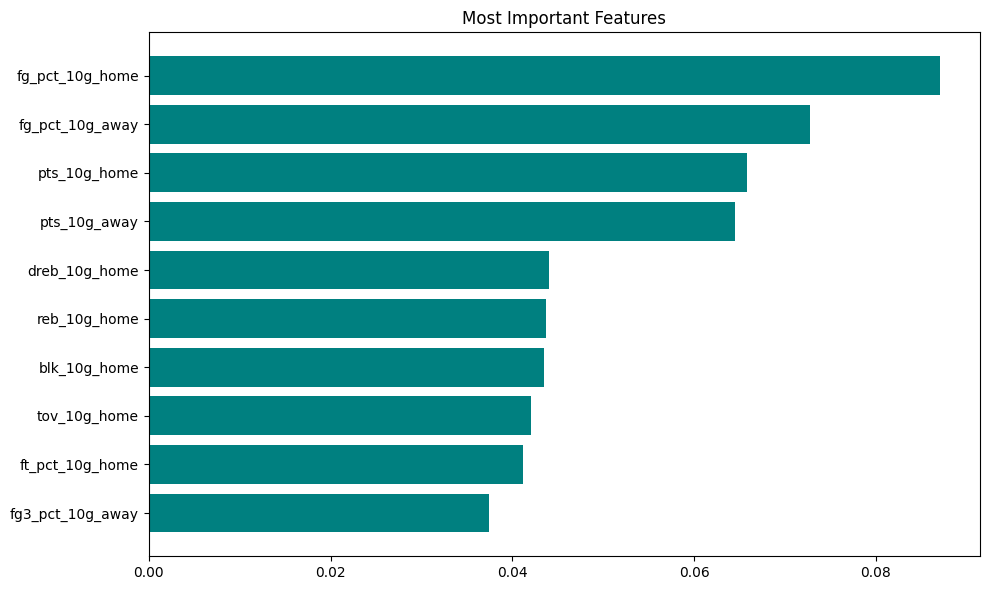

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Gather all of the feature Importances from the XGBoost model
importance = optimized_xgb.feature_importances_
feature_names = X_train.columns

# Create Dataframe and sort
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot It
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color='teal')
plt.title('Most Important Features')
plt.tight_layout()
plt.show()


### 8.2 Confusion Matrices


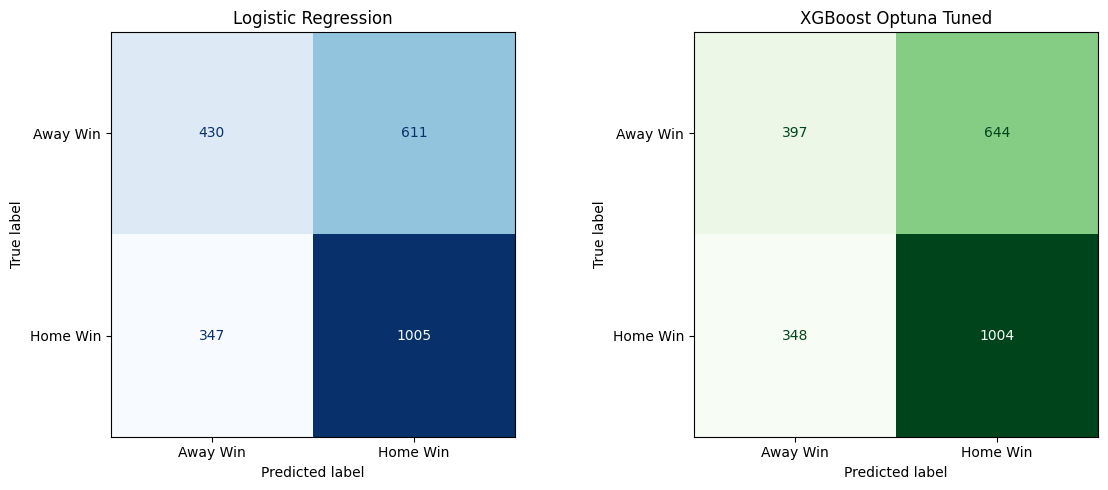

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1x2 plot grid
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['Away Win', 'Home Win'])
disp_log_reg.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')

# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_optuna)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Away Win', 'Home Win'])
disp_xgb.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('XGBoost Optuna Tuned')

plt.tight_layout()
plt.show()


### 8.3 ROC Curve and AUC Score

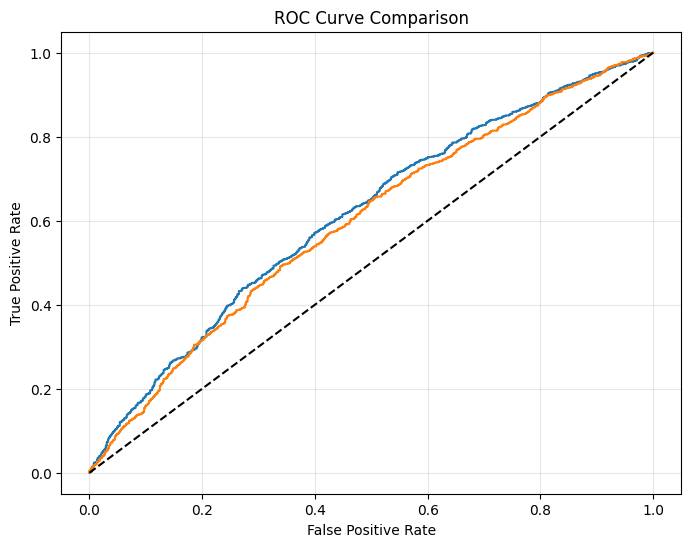

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predicted Probabilities
log_probs = baseline.predict_proba(X_test_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate the false positive rate (fpr) and the true positive rate (tpr)
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# Plot it
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f'LogReg (AUC = {auc(fpr_log, tpr_log):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.3f})')
plt.plot([0,1], [0, 1], 'k--', label='Random Guessing (AUC = 0.500)')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.show();



## 9. L1 Regularization (Lasso Regression)

In [ ]:
# First, train the lasso model
# Have to change to the solver to 'liblinear' because default doesn't support lasso
# A lower C value means more of the features will be pushed towards zero
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Predict and Evaluate how the model has done
y_pred_lasso = lasso_model.predict(X_test_scaled)
lasso_accuracy = accuracy_score(y_test, y_pred_lasso)
print(f"Lasso Accuracy: {lasso_accuracy * 100: .2f}%")

# Classification Report
print("Lasso Classification Report:")
print(classification_report(y_test, y_pred_lasso, target_names=['Away (0)', 'Home (1)']))

# Organize all of the coefficients
coefficients = lasso_model.coef_[0]
features = X_train.columns

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])

# Sort by the absolute coefficient size
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# See what Featrues were zeroed out
feat_zeroed = coef_df[coef_df['Coefficient'] == 0]
feat_active = coef_df[coef_df['Coefficient'] != 0]

print(f"Total Number of Features (Originally): {len(features)}")
print(f"Features reduced to zero: {len(feat_zeroed)}")
print(f"Active Features Remaining: {len(feat_active)}\n")

print("Eliminated Features:")
print(feat_zeroed['Feature'].tolist())
print("\n Strongest Predictors (Lasso):")
print(feat_active.head(5)[['Feature', 'Coefficient']])

Lasso Accuracy:  60.05%
Lasso Classification Report:
              precision    recall  f1-score   support

    Away (0)       0.55      0.41      0.47      1041
    Home (1)       0.62      0.74      0.68      1352

    accuracy                           0.60      2393
   macro avg       0.59      0.58      0.58      2393
weighted avg       0.59      0.60      0.59      2393

Total Number of Features (Originally): 24
Features reduced to zero: 3
Active Features Remaining: 21

Eliminated Features:
['oreb_10g_home', 'ast_10g_home', 'oreb_10g_away']

 Strongest Predictors (Lasso):
            Feature  Coefficient
0   fg_pct_10g_home     0.258320
12  fg_pct_10g_away    -0.191054
9      tov_10g_home    -0.186250
5      reb_10g_home     0.183137
7      stl_10g_home     0.146467
